**Task:**

1.Create the DataFrame from the given dataset.

2.Explore the dataset using head(), shape, and isnull().

3.Visualize Income vs Spending Score, separating customers who purchased and did not purchase.

4.Select Age, Income, and SpendingScore as the features.

5.Select Purchased as the target.

6.Split the data into training and testing data.

7.Train a *Logistic Regression* model.

8.Make predictions on the test data.

9.Calculate the accuracy of the model.

10.Visualize Actual vs Predicted values.

11.Predict whether a new customer will purchase the product.


In [ ]:
%load_ext watermark
%watermark -d -u -a "Aman Neupane"-v -p numpy,pandas,matplotlib,seaborn,sklearn

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Author: Binay Sharma

Last updated: 2026-08-25

Python implementation: CPython
Python version       : 3.13.15
IPython version      : 7.34.0

numpy     : 2.1.3
pandas    : 2.2.3
matplotlib: 3.10.0
seaborn   : 0.13.2
sklearn   : 1.6.1



In [118]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline



In [119]:
df= pd.DataFrame({
    "Age": [
        22, 25, 30, 35, 40,
        45, 50, 23, 28, 33,
        38, 42, 48, 52, 27,
        31, 36, 41, 46, 55
    ],

    "Income": [
        25000, 30000, 35000, 45000, 50000,
        60000, 70000, 28000, 32000, 40000,
        48000, 55000, 65000, 75000, 33000,
        38000, 47000, 58000, 68000, 80000
    ],

    "SpendingScore": [
        75, 80, 65, 60, 55,
        50, 40, 85, 70, 65,
        55, 50, 45, 35, 75,
        70, 60, 50, 45, 30
    ],

    "Purchased": [
        1, 1, 1, 1, 0,
        0, 0, 1, 1, 1,
        0, 0, 0, 0, 1,
        1, 1, 0, 0, 0
    ]
})



In [120]:
df.head()

,Age,Income,SpendingScore,Purchased
0,22,25000,75,1
1,25,30000,80,1
2,30,35000,65,1
3,35,45000,60,1
4,40,50000,55,0


In [121]:
print("shape:",df.shape)
print("isnull:",df.isnull().sum())


shape: (20, 4)
isnull: Age              0
Income           0
SpendingScore    0
Purchased        0
dtype: int64


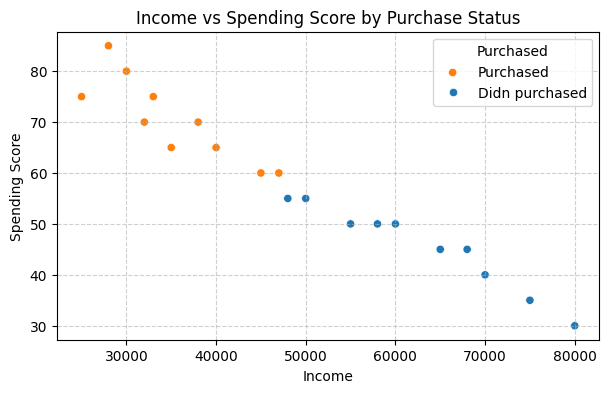

In [122]:
# Lets visualize data on the basis of Income and spending score
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Income', y='SpendingScore', hue='Purchased', data=df)
plt.title('Income vs Spending Score by Purchase Status')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.legend(title='Purchased', loc='upper right', labels=['Purchased', 'Didn purchased'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [123]:
input_data=df.drop("Purchased",axis=1)
target_data=df["Purchased"]
df.head()

,Age,Income,SpendingScore,Purchased
0,22,25000,75,1
1,25,30000,80,1
2,30,35000,65,1
3,35,45000,60,1
4,40,50000,55,0


In [124]:
#splitting data into train and test
x_train,x_test,y_train,y_test=train_test_split(input_data,target_data,test_size=0.2,random_state=42)


In [125]:
#Loading logistic regression model
model=LogisticRegression()
model.fit(x_train,y_train)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [126]:
#Making Predictions
predictions=model.predict(x_test)

In [127]:
#Accuracy Calculate
accuracy=accuracy_score(y_test,predictions)
print("Accuracy:",accuracy)
print("Due to small data, the model overfitted")


Accuracy: 1.0
Due to small data, the model overfitted


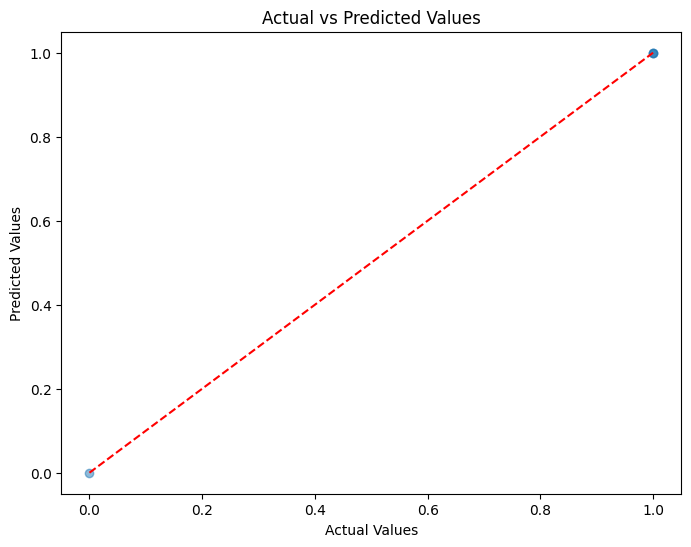

In [128]:
#Visualization of prediction and actual values
plt.figure(figsize=(8,6))
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.scatter(y_test,predictions,alpha=0.5)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],linestyle="--",color="red")

In [129]:

new_user = pd.DataFrame({
    "Age": [25],
    "Income": [80000],
    "SpendingScore": [20]
})

print("New User Data :")
display(new_user)

New User Data :


,Age,Income,SpendingScore
0,25,80000,20


In [130]:
# Predict for the new user
predicted_purchase = model.predict(new_user)

print("Prediction for this user:", predicted_purchase)

if predicted_purchase[0] == 1:
    print("This user is predicted to purchase the product.")
else:
    print("This user is predicted not to purchase the product.")

Prediction for this user: [0]
This user is predicted not to purchase the product.
